In [5]:
from sklearn.datasets import fetch_openml
import pandas as pd

# Cargar dataset real desde OpenML
data = fetch_openml(name='default-of-credit-card-clients', version=1, as_frame=True)

# Convertir a DataFrame
df = data.frame

# Visualizar los primeros registros
print(df.shape)
df.head()

(30000, 24)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x15,x16,x17,x18,x19,x20,x21,x22,x23,y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## Descripción general
Este conjunto de datos contiene información financiera y demográfica de 30,000 clientes de tarjetas de crédito, con el fin de predecir si el cliente incumplirá el pago del mes siguiente (default.payment.next.month). Es ideal para segmentación de riesgo, clasificación crediticia y análisis de comportamiento financiero en contextos como SAGRILAFT

| Variable                        | Descripción                                                                                                                           |
| ------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------- |
| **ID**                          | Identificador del cliente                                                                                                             |
| **LIMIT\_BAL**                  | Monto del crédito otorgado (en NT\$)                                                                                                  |
| **SEX**                         | Género (1 = Masculino, 2 = Femenino)                                                                                                  |
| **EDUCATION**                   | Nivel educativo (1 = posgrado, 2 = universidad, 3 = secundaria, 4 = otros)                                                            |
| **MARRIAGE**                    | Estado civil (1 = casado, 2 = soltero, 3 = otros)                                                                                     |
| **AGE**                         | Edad del cliente en años                                                                                                              |
| **PAY\_0** a **PAY\_6**         | Historial de pagos (estado de reembolso desde septiembre hasta abril, donde -1 = pago debidamente, 0 = al día, 1-9 = demora en meses) |
| **BILL\_AMT1** a **BILL\_AMT6** | Monto de la factura por mes (últimos 6 meses)                                                                                         |
| **PAY\_AMT1** a **PAY\_AMT6**   | Monto del pago realizado por mes (últimos 6 meses)                                                                                    |
| **default.payment.next.month**  | Variable objetivo: 1 = incumplimiento de pago, 0 = pago realizado                                                                     |


#Segmentacion 

Se Propone una segmentación no supervisada primero (clustering), y luego analizar qué segmentos están asociados a mayor riesgo a partir de variables de alerta. Esto es muy coherente con un enfoque SAGRILAFT basado en perfiles.

| Variable      | Descripción breve                 |
| ------------- | --------------------------------- |
| `LIMIT_BAL`   | Crédito otorgado                  |
| `AGE`         | Edad del cliente                  |
| `BILL_AMT1-6` | Monto de facturación mensual      |
| `PAY_AMT1-6`  | Monto de pagos realizados por mes |


In [7]:
# Paso 1: Librerías
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Paso 2: Cargar dataset
data = fetch_openml(name='default-of-credit-card-clients', version=1, as_frame=True)
df = data.frame



# Paso 3: Renombrar columnas manualmente
df.columns = [
    "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
    "default.payment.next.month"
]

# Paso 4: Variables para clustering
variables_segmentacion = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

X = df[variables_segmentacion]


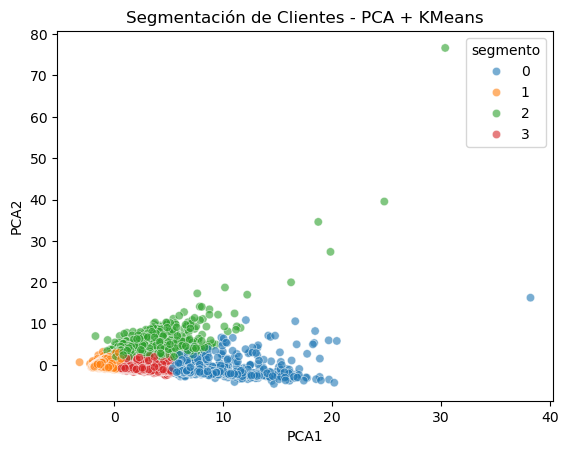

In [9]:
#: Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Paso 7: KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)

##  Aplicar KMedoids con distintas métricas
# Puedes cambiar el parámetro metric por:
# 'euclidean'  -> Distancia clásica (por defecto). Usa reglas tipo Pitágoras.
# 'manhattan'  -> Más robusta a outliers. Suma de valores absolutos.
# 'cosine'     -> Útil cuando importa la dirección más que la magnitud (por ejemplo, textos).
# 'precomputed'-> Si ya calculaste tú mismo una matriz de distancias personalizada.

df["segmento"] = kmeans.fit_predict(X_scaled)

# Paso 6: PCA para visualización
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


# Paso 8: Visualizar clusters
df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="segmento", palette="tab10", alpha=0.6)
plt.title("Segmentación de Clientes - PCA + KMeans")
plt.show()

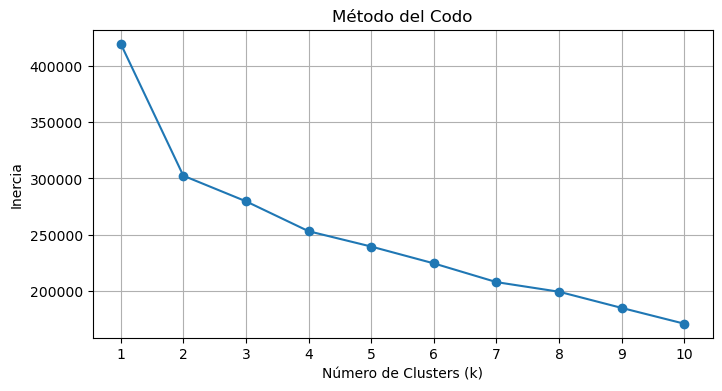

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled) 
    inertias.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

#  Comparación de Inercia: 1 clúster vs 2 clústeres en K-Means

## 🔢 Datos de ejemplo (en 2 dimensiones)

Tenemos los siguientes puntos:

```text
X = {(1, 2), (2, 1), (1, 1), (8, 8), (9, 9), (8, 9)}
```

Visualmente, hay dos grupos:

- Grupo A: cerca de (1,1)
- Grupo B: cerca de (9,9)

---

## 🚶 Paso 1: Agrupamos en **1 clúster** (k = 1)

1. **Centroide general**:

$$
\mu = \left( \frac{1+2+1+8+9+8}{6}, \frac{2+1+1+8+9+9}{6} \right) = (4.83, 5)
$$

2. **Distancia al cuadrado** desde cada punto al centroide:

| Punto     | Distancia al cuadrado \(\|x_i - \mu\|^2\) |
|-----------|--------------------------------------------|
| (1,2)     | ≈ 27.55                                     |
| (2,1)     | ≈ 29.89                                     |
| (1,1)     | ≈ 33.22                                     |
| (8,8)     | ≈ 15.55                                     |
| (9,9)     | ≈ 34.22                                     |
| (8,9)     | ≈ 26.89                                     |

3. **Inercia total con k = 1**:

```text
Inercia ≈ 167.32
```

---

## 🧪 Paso 2: Agrupamos en **2 clústeres** (k = 2)

Asignamos:

- Clúster 1: (1,2), (2,1), (1,1)
- Clúster 2: (8,8), (9,9), (8,9)

### Clúster 1

- Centroide: (1.33, 1.33)

| Punto     | Distancia al cuadrado |
|-----------|------------------------|
| (1,2)     | ≈ 0.44                 |
| (2,1)     | ≈ 0.44                 |
| (1,1)     | ≈ 0.22                 |

**Subtotal Clúster 1**: ≈ 1.11

### Clúster 2

- Centroide: (8.33, 8.67)

| Punto     | Distancia al cuadrado |
|-----------|------------------------|
| (8,8)     | ≈ 0.44                 |
| (9,9)     | ≈ 0.44                 |
| (8,9)     | ≈ 0.11                 |

**Subtotal Clúster 2**: ≈ 0.99

### **Inercia total con k = 2**:

```text
Inercia ≈ 1.11 + 0.99 = 2.10
```

---

## 📊 Comparación de Inercia

| Número de Clústeres (k) | Inercia Total |
|-------------------------|----------------|
| 1                       | 167.32          |
| 2                       | 2.10            |

---

## ✅ Conclusión

- Al dividir los datos en **2 clústeres**, la inercia baja **drásticamente**.
- Este cambio fuerte es lo que detecta el **método del codo**.
- A partir de cierto punto, aumentar \( k \) **ya no mejora mucho la inercia**.


In [17]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,segmento,PCA1,PCA2
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,689,0,0,0,0,1,1,-1.958481,-0.537045
1,120000,2,2,2,26,-1,2,0,0,0,...,0,1000,1000,1000,0,2000,1,1,-1.735307,-0.217341
2,90000,2,2,2,34,0,0,0,0,0,...,1518,1500,1000,1000,1000,5000,0,1,-1.224240,-0.284887
3,50000,2,2,1,37,0,0,0,0,0,...,2000,2019,1200,1100,1069,1000,0,1,-0.540935,-0.666624
4,50000,1,2,1,57,-1,0,-1,0,0,...,2000,36681,10000,9000,689,679,0,1,-0.848741,0.739026


In [55]:
df["segmento"] = kmeans.fit_predict(X_scaled)

## ¿Qué sigue?



## Paso 2: Asociar los segmentos con variables de alerta
Vamos a:

Crear variables de alerta:

Clientes con todos los pagos en 0

Alta deuda acumulada (facturación alta vs pagos bajos)

Alto uso del crédito otorgado

Crear un resumen descriptivo por segmento.

In [57]:
import pandas as pd

#  Asegurarse de que la variable objetivo esté en formato numérico
df["default.payment.next.month"] = pd.to_numeric(df["default.payment.next.month"], errors="coerce")

# - pagos_en_cero
# - deuda_acumulada
# - uso_credito
# - segmento

# Si no las tienes, aquí van algunos ejemplos:
df["pagos_en_cero"] = df[[f"PAY_AMT{i}" for i in range(1, 7)]].sum(axis=1) == 0
df["deuda_acumulada"] = df[[f"BILL_AMT{i}" for i in range(1, 7)]].sum(axis=1)
df["uso_credito"] = df["deuda_acumulada"] / (df["LIMIT_BAL"] + 1)


# 3. Tabla resumen por segmento
resumen_segmentos = df.groupby("segmento").agg({
    "pagos_en_cero": lambda x: round(x.mean() * 100, 2),                     # % con pagos en 0
    "deuda_acumulada": "mean",                                              # Deuda acumulada promedio
    "uso_credito": "mean",                                                  # Uso promedio del crédito
    "LIMIT_BAL": "mean",                                                    # Crédito promedio otorgado
    "AGE": "mean",                                                          # Edad promedio
    "default.payment.next.month": lambda x: round(x.mean() * 100, 2),       # % en default
    "segmento": "count"                                                     # Número de clientes por segmento
}).rename(columns={
    "pagos_en_cero": "% con pagos en 0",
    "deuda_acumulada": "Deuda acumulada promedio",
    "uso_credito": "Uso promedio del crédito",
    "LIMIT_BAL": "Crédito promedio otorgado",
    "AGE": "Edad promedio",
    "default.payment.next.month": "% con default",
    "segmento": "N° de clientes"
}).round(2)

# 4. Mostrar tabla final
print("\n📊 Resumen tipo tabla dinámica por segmento:\n")
print(resumen_segmentos.to_string())


📊 Resumen tipo tabla dinámica por segmento:

          % con pagos en 0  Deuda acumulada promedio  Uso promedio del crédito  Crédito promedio otorgado  Edad promedio  % con default  N° de clientes
segmento                                                                                                                                               
0                     0.17                1609910.76                      4.80                  350359.14          38.26          22.53            1163
1                     6.30                 105124.66                      1.74                  144498.19          35.20          23.09           22654
2                     0.00                 448647.89                      1.60                  338280.32          36.95           7.46            1006
3                     0.06                 654952.69                      3.98                  193797.57          35.81          20.65            5177


## Sistema de alertas EJEMPLO 

In [173]:
# 1. Alerta de riesgo por no pago (morosidad total)
df["alerta_pagos_en_cero"] = (df[[f"PAY_AMT{i}" for i in range(1, 7)]].sum(axis=1) == 0).astype(int)

#Alerta por acumulación sin abono (sospecha de lavado o sobreendeudamiento)
df["alerta_acumulacion_sin_abono"] = df["BILL_AMT6"] > 3 * df["PAY_AMT6"]

#3. Alerta por uso elevado del crédito
df["uso_credito"] = df[[f"BILL_AMT{i}" for i in range(1, 7)]].mean(axis=1) / df["LIMIT_BAL"]
df["alerta_uso_credito_alto"] = df["uso_credito"] > 0.9


#Alerta por pagos mínimos con límite alto
limite_promedio = df["LIMIT_BAL"].mean()
df["alerta_limite_alto_pago_minimo"] = (df["LIMIT_BAL"] > limite_promedio) & \
                                        (df["PAY_AMT6"] < 0.05 * df["LIMIT_BAL"])


#7. Alerta por facturación alta reciente sin pago
df["alerta_factura_sin_pago"] = (df["BILL_AMT6"] > df["BILL_AMT5"] * 1.5) & (df["PAY_AMT6"] == 0)


# Distancia euclidiana desde el origen
df["distancia_pca"] = np.sqrt(df["PCA1"]**2 + df["PCA2"]**2)

# Umbral como percentil 95 (top 5% más alejados)
umbral = df["distancia_pca"].quantile(0.95)

# Alerta por outlier PCA
df["alerta_outlier_pca"] = df["distancia_pca"] > umbral

In [175]:
df.head(20)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PCA1,PCA2,alerta_pagos_en_cero,alerta_acumulacion_sin_abono,uso_credito,alerta_uso_credito_alto,alerta_limite_alto_pago_minimo,alerta_factura_sin_pago,distancia_pca,alerta_outlier_pca
0,20000,2,2,1,24,2,2,-1,-1,-2,...,-1.958481,-0.537045,0,False,0.064200,False,False,False,2.030779,False
1,120000,2,2,2,26,-1,2,0,0,0,...,-1.735307,-0.217341,0,False,0.023718,False,False,False,1.748865,False
2,90000,2,2,2,34,0,0,0,0,0,...,-1.224240,-0.284887,0,True,0.188246,False,False,False,1.256950,False
3,50000,2,2,1,37,0,0,0,0,0,...,-0.540935,-0.666624,0,True,0.771113,False,False,False,0.858486,False
4,50000,1,2,1,57,-1,0,-1,0,0,...,-0.848741,0.739026,0,True,0.364463,False,False,False,1.125399,False
5,50000,1,1,2,37,0,0,0,0,0,...,-0.536934,-0.711996,0,True,0.793713,False,False,False,0.891760,False
6,500000,1,1,2,29,0,0,0,0,0,...,15.880763,-0.961255,0,True,0.908198,True,True,False,15.909828,True
7,100000,2,2,2,23,0,-1,-1,0,0,...,-1.802214,-0.292339,0,False,0.022477,False,False,False,1.825770,False
8,140000,2,3,1,28,0,0,2,0,0,...,-1.409711,-0.208825,0,True,0.077633,False,False,False,1.425094,False
9,20000,1,3,2,35,-2,-2,-2,-2,-1,...,-1.685796,-0.176236,0,True,0.224325,False,False,False,1.694983,False


In [ ]:
#--from google.colab import files

# Guardar como archivo Excel
df.to_excel("Segementación.xlsx", index=False)

# Descargar
##--files.download("Segementación.xlsx")